# Lab-6

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np
import random

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Load and Preprocess CIFAR-10

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

It normalizes the RGB image channels so that pixel values are centered around zero and scaled to the range [-1,1], which improves neural network training stability and learning efficiency.

## Select 10000 Random Images

In [ ]:
indices = list(range(len(dataset)))
random.shuffle(indices)

subset_indices = indices[:10000]

subset_dataset = Subset(dataset, subset_indices)

dataloader = DataLoader(
    subset_dataset,
    batch_size=128,
    shuffle=True
)

##Denormalization for Display

In [ ]:
def denormalize(img):
    img = img * 0.5 + 0.5
    return img

This function converts normalized image pixel values from the range [-1,1] back to the range [0,1] so that the images can be displayed correctly using matplotlib.

## Display One Image From Each Class

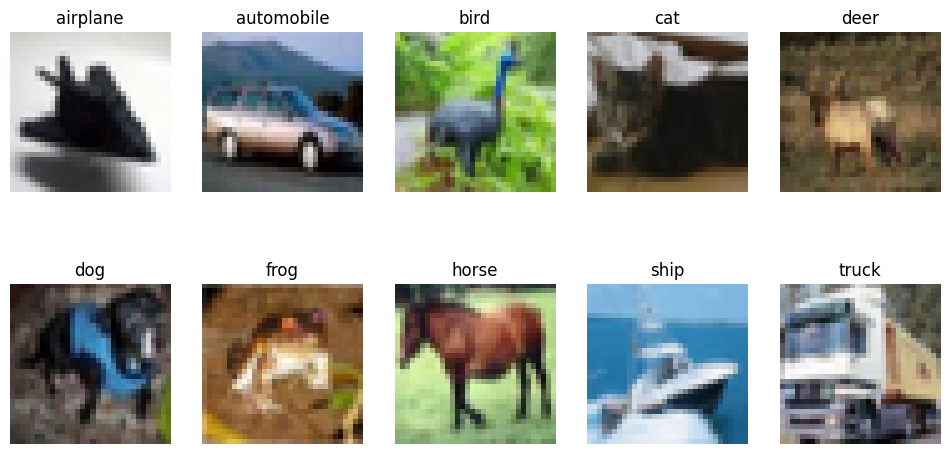

In [ ]:
classes = dataset.classes
shown = set()

plt.figure(figsize=(12,6))

for img,label in dataset:

    if label not in shown:

        plt.subplot(2,5,label+1)

        img = denormalize(img)

        plt.imshow(np.transpose(img.numpy(),(1,2,0)))
        plt.title(classes[label])
        plt.axis("off")

        shown.add(label)

    if len(shown)==10:
        break

plt.show()

##Sparse Autoencoder Model

In [ ]:
class SparseAutoencoder(nn.Module):

    def __init__(self, in_dims=3072, h_dims=2048,
                 sparsity_lambda=1e-5, sparsity_target=0.05):

        super().__init__()

        self.sparsity_lambda = sparsity_lambda
        self.sparsity_target = sparsity_target

        self.encoder = nn.Sequential(
            nn.Linear(in_dims, h_dims),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(h_dims, in_dims),
            nn.Tanh()
        )

    def forward(self,x):

        encoded = self.encoder(x)
        decoded = self.decoder(encoded)

        return encoded, decoded

This code defines a Sparse Autoencoder model in PyTorch where the encoder compresses the 3072-dimensional CIFAR-10 image into a 2048-dimensional feature representation, and the decoder reconstructs the original image from these features while enforcing sparsity on the hidden neurons.

##Sparsity Penalty

In [ ]:
def sparsity_penalty(encoded, target=0.05):

    rho_hat = torch.mean(encoded,dim=0)

    rho_hat = torch.clamp(rho_hat,1e-8,1-1e-8)

    rho = target

    kl = rho * torch.log(rho/rho_hat) + \
         (1-rho) * torch.log((1-rho)/(1-rho_hat))

    return torch.sum(kl)

This function computes the KL-divergence between the desired neuron activation level and the actual activation of hidden neurons, encouraging the network to keep most neurons inactive so that the autoencoder learns sparse and meaningful feature representations.

##Loss Function

Total Loss = Reconstruction Loss + Sparsity Penalty

In [ ]:
def loss_function(x_hat,x,encoded):

    mse = F.mse_loss(x_hat,x)

    sparse = sparsity_penalty(encoded)

    return mse + 1e-5*sparse

## Model Initialization

In [ ]:
model = SparseAutoencoder().to(device)

optimizer = torch.optim.Adam(model.parameters(),lr=0.0001)

epochs = 80

train_losses = []

## Training

In [ ]:
for epoch in range(epochs):

    total_loss = 0

    for images,_ in dataloader:

        images = images.view(images.size(0),-1).to(device)

        optimizer.zero_grad()

        encoded,decoded = model(images)

        loss = loss_function(decoded,images,encoded)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss/len(dataloader)

    train_losses.append(avg_loss)

    print("Epoch",epoch+1,"Loss:",avg_loss)

Epoch 1 Loss: 0.11526936452977266
Epoch 2 Loss: 0.06144505347820777
Epoch 3 Loss: 0.04770625156315067
Epoch 4 Loss: 0.04011617610348931
Epoch 5 Loss: 0.03508402062933656
Epoch 6 Loss: 0.03131990870342979
Epoch 7 Loss: 0.02849140147902543
Epoch 8 Loss: 0.026178193903422055
Epoch 9 Loss: 0.024308821162845516
Epoch 10 Loss: 0.02273313302688206
Epoch 11 Loss: 0.021369296491523332
Epoch 12 Loss: 0.020262262111977687
Epoch 13 Loss: 0.019194153903783123
Epoch 14 Loss: 0.018284418773424776
Epoch 15 Loss: 0.017556784698103046
Epoch 16 Loss: 0.016886485905586918
Epoch 17 Loss: 0.016185221333009533
Epoch 18 Loss: 0.01554930377515811
Epoch 19 Loss: 0.015008933405993106
Epoch 20 Loss: 0.014549048252026492
Epoch 21 Loss: 0.014034627441646932
Epoch 22 Loss: 0.013677699526748325
Epoch 23 Loss: 0.013292885597653781
Epoch 24 Loss: 0.012898435792590998
Epoch 25 Loss: 0.012542314131897462
Epoch 26 Loss: 0.012260510138224196
Epoch 27 Loss: 0.011956691329332091
Epoch 28 Loss: 0.011621510739662225
Epoch 29 L

##Plot Training Loss Graph

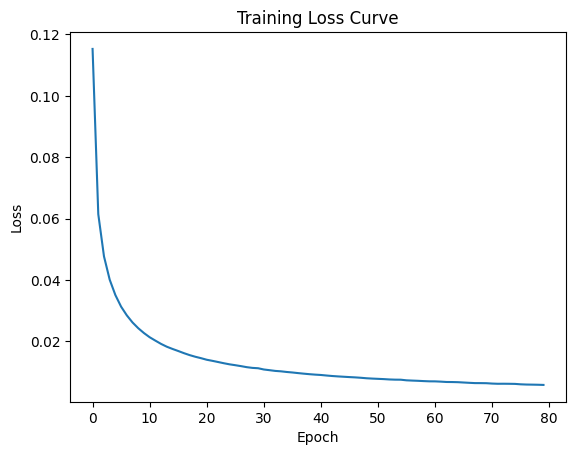

In [ ]:
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

This graph shows how the training loss decreases over epochs while training the Sparse Autoencoder. Initially the loss is high, but it gradually reduces as the model learns better feature representations and improves image reconstruction. The steady downward trend indicates that the model is learning effectively and converging during training.

##Validation (Reconstruction Loss)

Autoencoders do not measure classification accuracy.
Evaluation is based on reconstruction loss.

In [ ]:
model.eval()

val_loss = 0

with torch.no_grad():

    for images,_ in dataloader:

        images = images.view(images.size(0),-1).to(device)

        encoded,decoded = model(images)

        loss = loss_function(decoded,images,encoded)

        val_loss += loss.item()

print("Validation Loss:", val_loss/len(dataloader))

Validation Loss: 0.005689215280492849


The validation loss (0.005689) represents how well the trained Sparse Autoencoder reconstructs unseen images from the dataset. It measures the difference between the original images and the reconstructed images using the reconstruction loss (MSE) along with the sparsity penalty.

A small value like 0.0057 indicates that the reconstructed images are very close to the original images, meaning the model has learned good feature representations and is performing well on the validation data.

##Testing on 5-7 Images

In [ ]:
test_loader = DataLoader(dataset,batch_size=1,shuffle=True)

original=[]
reconstructed=[]

with torch.no_grad():

    for img,_ in test_loader:

        img_flat = img.view(1,-1).to(device)

        enc,dec = model(img_flat)

        original.append(img.squeeze())

        reconstructed.append(dec.cpu().view(3,32,32).squeeze())

        if len(original)==7:
            break

##Display Reconstruction Results

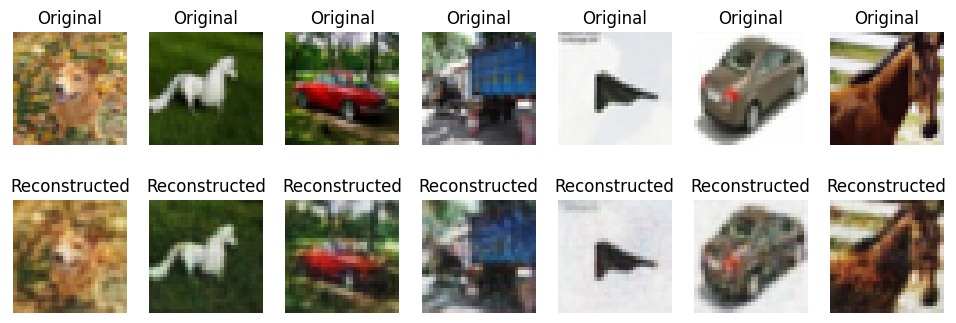

In [ ]:
plt.figure(figsize=(12,4))

for i in range(7):

    plt.subplot(2,7,i+1)

    plt.imshow(np.transpose(denormalize(original[i]).numpy(),(1,2,0)))

    plt.title("Original")
    plt.axis("off")

    plt.subplot(2,7,i+8)

    plt.imshow(np.transpose(denormalize(reconstructed[i]).numpy(),(1,2,0)))

    plt.title("Reconstructed")
    plt.axis("off")

plt.show()

Here we compares the original CIFAR-10 images (top row) with the reconstructed images produced by the Sparse Autoencoder (bottom row). The reconstructed images preserve the overall shapes, colors, and major structures of the original images, although some details appear slightly blurred.

This shows that the autoencoder has successfully learned compressed feature representations and can reconstruct the input images reasonably well from those learned features.